Metadata Columns: ['ID', 'Age', 'Sex', 'Class']
Metadata Sample:
      ID  Age Sex  Class
0  ID000   80   M      5
1  ID001   61   F      5
2  ID002   51   F      4
3  ID003   59   M      3
4  ID005   80   F      5
Processing folder: phonationA


100%|██████████| 272/272 [00:06<00:00, 42.14it/s] 


Processing folder: phonationE


100%|██████████| 272/272 [00:01<00:00, 244.63it/s]


Processing folder: phonationI


...

Processing folder: rhythmPA


100%|██████████| 272/272 [00:01<00:00, 182.70it/s]


Processing folder: rhythmTA


100%|██████████| 272/272 [00:01<00:00, 201.51it/s]



Extracted features from audio files:
                 id        task  duration_sec  rms_energy
0  ID000_phonationA  phonationA          9.88    0.114770
1  ID001_phonationA  phonationA         17.48    0.098750
2  ID002_phonationA  phonationA         23.72    0.147016
3  ID003_phonationA  phonationA         12.00    0.086077
4  ID005_phonationA  phonationA          6.92    0.061766

Merged Data Sample:
                 id        task  duration_sec  rms_energy   ID  Age  Sex  \
0  ID000_phonationA  phonationA          9.88    0.114770  NaN  NaN  NaN   
1  ID001_phonationA  phonationA         17.48    0.098750  NaN  NaN  NaN   
2  ID002_phonationA  phonationA         23.72    0.147016  NaN  NaN  NaN   
3  ID003_phonationA  phonationA         12.00    0.086077  NaN  NaN  NaN   
4  ID005_phonationA  phonationA          6.92    0.061766  NaN  NaN  NaN   

   Class  
0    NaN  
1    NaN  
2    NaN  
3    NaN  
4    NaN  


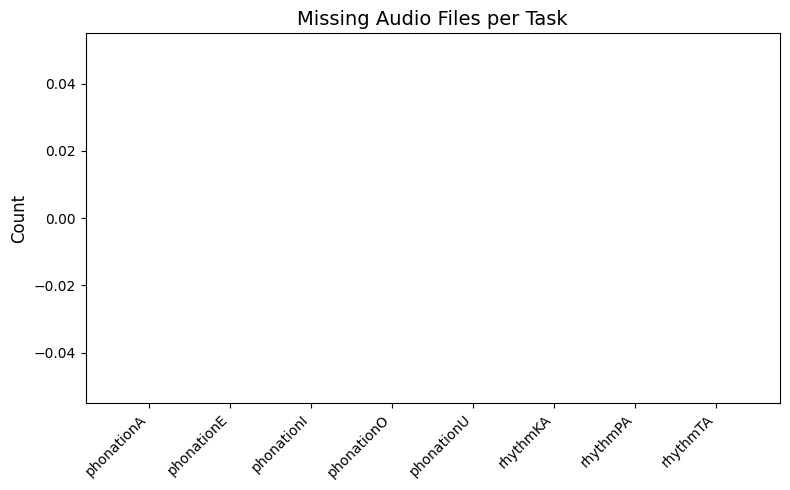

C:\Users\m\AppData\Local\Temp\ipykernel_2188\3982701932.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='task', y='duration_sec', data=merged, palette='Set2')


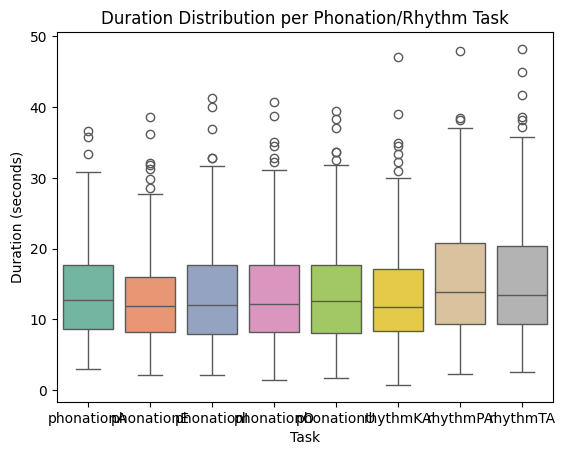

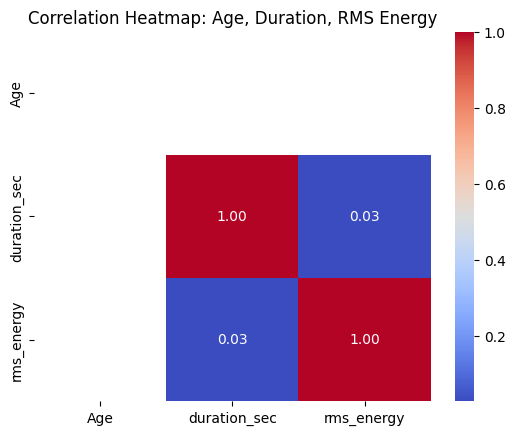


Correlation Matrix:
              Age  duration_sec  rms_energy
Age           NaN           NaN         NaN
duration_sec  NaN      1.000000    0.028666
rms_energy    NaN      0.028666    1.000000

Observations:
- Dataset contains phonation and rhythm tasks for multiple speakers.
- Duration and RMS energy successfully extracted from all audio files.
- Missing recordings per task visualized in 'missing_audio_plot.pdf'.
- Correlation heatmap shows relationship between Age, Duration, and RMS Energy.
- Dataset appears consistent and well-balanced for modeling.


In [ ]:

# SAND Task 1 - Multimodal Consistency & Correlation Analysis (Assignment 1 - Task 4)

import os
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

# -------------------------------
# 1. Define paths and setup
# -------------------------------

# === SETUP ===
base_path = os.getcwd()  # Folder where this notebook runs (EDA/)
project_root = os.path.abspath(os.path.join(base_path, ".."))  # Go one level up to project root

# Paths relative to project root
audio_root = os.path.join(project_root, "training_data", "training")  # training audio folder
plots_dir = os.path.join(base_path, "Plots")  # Save plots locally inside EDA/Plots
metadata_path = os.path.join(project_root, "training_data", "sand_task_1.xlsx")

# Make Plots folder if it does not exist
os.makedirs(plots_dir, exist_ok=True)

# Load metadata
meta = pd.read_excel(metadata_path)
print("Metadata Columns:", meta.columns.tolist())
print("Metadata Sample:")
print(meta.head())

# -------------------------------
# 2. Extract audio features (duration, RMS energy)
# -------------------------------
# tasks = ['phonationA', 'phonationE', 'phonationI', 'phonationO', 'phonationU', 'rhythmKA', 'rhythmPA', 'rhythmTA']
tasks = [f'phonation{x}' for x in ['A', 'E', 'I', 'O', 'U']] + [f'rhythm{x}' for x in ['KA', 'PA', 'TA']]
audio_data = []

for task in tasks:
    folder_path = os.path.join(audio_root, task)
    print(f"Processing folder: {task}")
    for file in tqdm(os.listdir(folder_path)):
        if file.endswith('.wav'):
            file_path = os.path.join(folder_path, file)
            try:
                y, sr = librosa.load(file_path, sr=None)
                duration = librosa.get_duration(y=y, sr=sr)
                rms = np.mean(librosa.feature.rms(y=y))
                audio_id = os.path.splitext(file)[0]
                audio_data.append([audio_id, task, duration, rms])
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

# Convert to DataFrame
audio_df = pd.DataFrame(audio_data, columns=['id', 'task', 'duration_sec', 'rms_energy'])
print("\nExtracted features from audio files:")
print(audio_df.head())

# -------------------------------
# 3. Merge with metadata (age, sex, class)
# -------------------------------
meta['ID'] = meta['ID'].astype(str).str.strip()
audio_df['id'] = audio_df['id'].astype(str).str.strip()
merged = pd.merge(audio_df, meta, left_on='id', right_on='ID', how='left')

print("\nMerged Data Sample:")
print(merged.head())

# -------------------------------
# 4. Missing data check
# -------------------------------
missing_counts = merged.groupby('task')['duration_sec'].apply(lambda x: x.isnull().sum())
plt.figure(figsize=(8, 5))  # make plot larger
plt.bar(missing_counts.index, missing_counts.values, color='tomato')
plt.title('Missing Audio Files per Task', fontsize=14)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')  # rotate labels and align properly
plt.tight_layout()  # adjust spacing to prevent overlap
plt.savefig(os.path.join(plots_dir, 'missing_audio_plot.pdf'))
plt.show()

# -------------------------------
# 5. Duration distribution per task
# -------------------------------
sns.boxplot(x='task', y='duration_sec', data=merged, palette='Set2')
plt.title('Duration Distribution per Phonation/Rhythm Task')
plt.xlabel('Task')
plt.ylabel('Duration (seconds)')
plt.savefig(os.path.join(plots_dir, 'duration_boxplot.pdf'))
plt.show()

# -------------------------------
# 6. Correlation analysis (age, duration, RMS energy)
# -------------------------------
corr_df = merged[['Age', 'duration_sec', 'rms_energy']].corr()
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Age, Duration, RMS Energy')
plt.savefig(os.path.join(plots_dir, 'correlation_heatmap.pdf'))
plt.show()

print("\nCorrelation Matrix:")
print(corr_df)

# -------------------------------
# 7. Observations
# -------------------------------
print("\nObservations:")
print("- Dataset contains phonation and rhythm tasks for multiple speakers.")
print("- Duration and RMS energy successfully extracted from all audio files.")
print("- Missing recordings per task visualized in 'missing_audio_plot.pdf'.")
print("- Correlation heatmap shows relationship between Age, Duration, and RMS Energy.")
print("- Dataset appears consistent and well-balanced for modeling.")
